In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/energy_data_set.csv'
)

In [ ]:
df.shape

(19735, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [ ]:
df.describe()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:30:00,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634


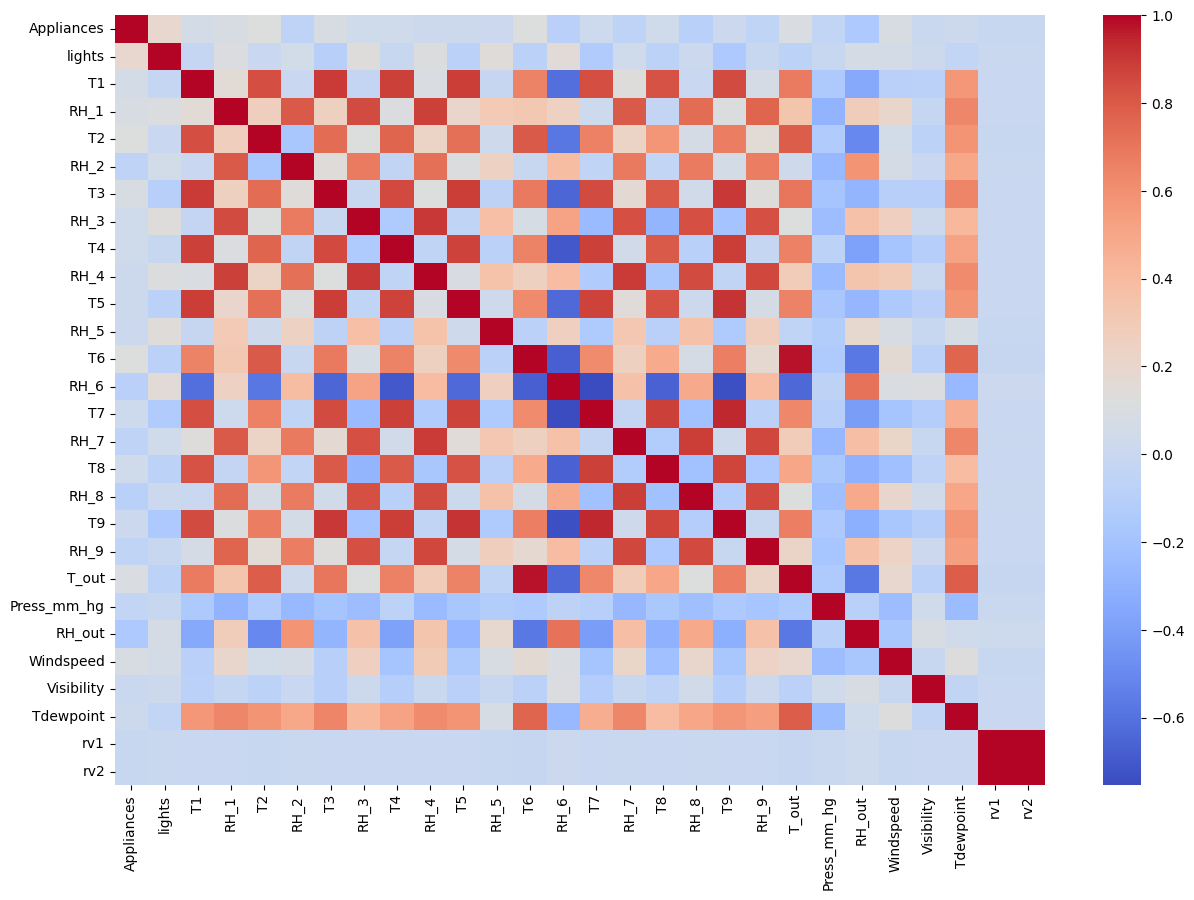

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')
plt.show()

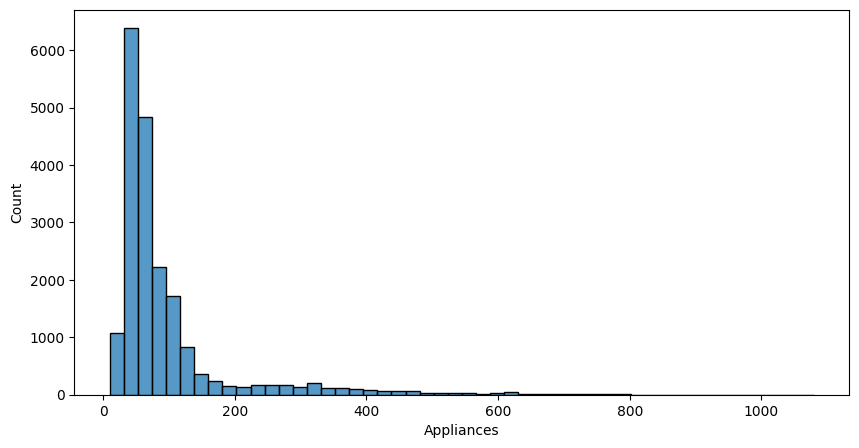

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Appliances'], bins=50)
plt.show()

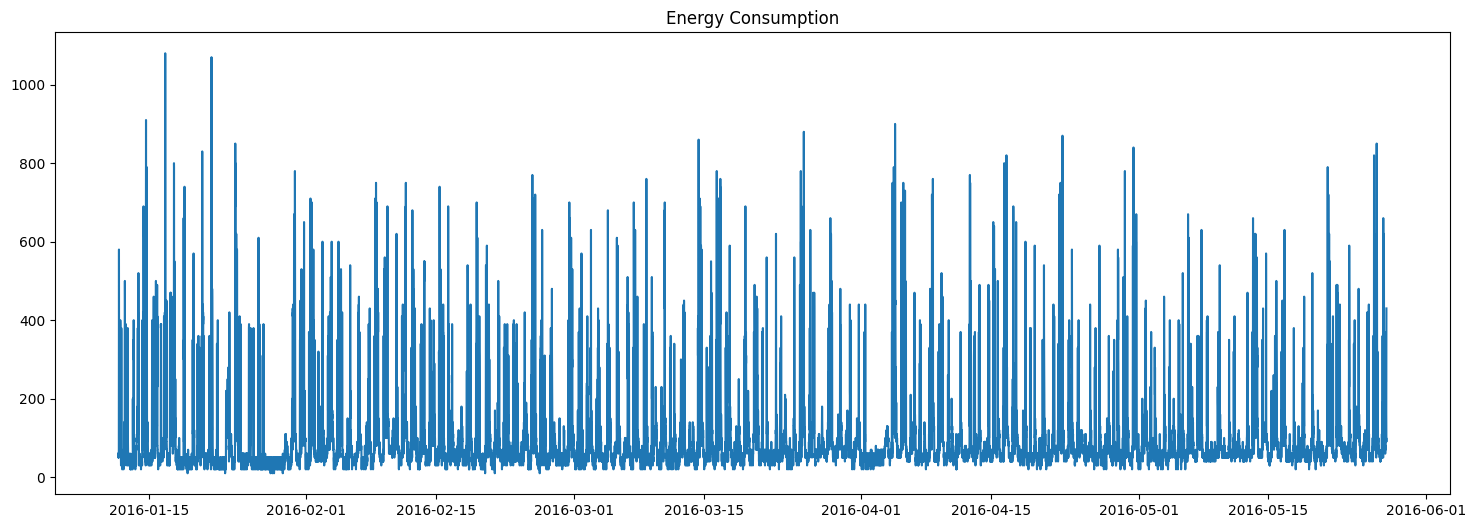

In [ ]:
plt.figure(figsize=(18,6))
plt.plot(df['date'], df['Appliances'])
plt.title("Energy Consumption")
plt.show()

In [ ]:
df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [ ]:
df = df.interpolate()

In [ ]:
df.fillna(df.mean(numeric_only=True),
          inplace=True)

In [ ]:
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
df = df[
    (df['Appliances'] >= lower) &
    (df['Appliances'] <= upper)
]

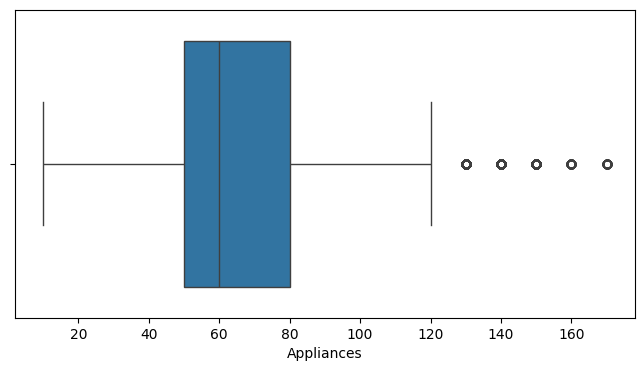

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Appliances'])
plt.show()

In [ ]:
df['hour'] = df['date'].dt.hour

In [ ]:
df['day'] = df['date'].dt.day

In [ ]:
df['month'] = df['date'].dt.month

In [ ]:
df['dayofweek'] = df['date'].dt.dayofweek

In [ ]:
df['weekend'] = (
    df['dayofweek'] >= 5
).astype(int)

In [ ]:
df['rolling_1h'] = (
    df['Appliances']
    .rolling(window=6)
    .mean()
)

In [ ]:
df['rolling_3h'] = (
    df['Appliances']
    .rolling(window=18)
    .mean()
)

In [ ]:
df['lag_1'] = df['Appliances'].shift(1)

In [ ]:
df['lag_3'] = df['Appliances'].shift(3)

In [ ]:
df['lag_6'] = df['Appliances'].shift(6)

In [ ]:
df['temp_humidity'] = (
    df['T_out'] *
    df['RH_out']
)

In [ ]:
df['windspeed_temp'] = (
    df['Windspeed'] *
    df['T_out']
)

In [ ]:
df.dropna(inplace=True)

In [ ]:
X = df.drop(
    ['Appliances','date'],
    axis=1
)

y = df['Appliances']

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X,y)

RandomForestRegressor(random_state=42)

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(20)

,Feature,Importance
32,rolling_1h,0.695988
34,lag_1,0.044106
35,lag_3,0.033851
27,hour,0.014423
33,rolling_3h,0.013343
36,lag_6,0.011724
20,Press_mm_hg,0.009798
10,RH_5,0.008397
23,Visibility,0.008182
15,T8,0.007474


In [ ]:
top_features = (
    importance
    .sort_values(
        'Importance',
        ascending=False
    )
    .head(15)
    ['Feature']
    .tolist()
)

X = X[top_features]

In [ ]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = lr.predict(
    X_test_scaled
)

In [ ]:
mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr
    )
)

print(mae_lr, rmse_lr)

8.876590699484604 13.123795721141802


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

pred_rf = rf.predict(
    X_test_scaled
)

In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

print(mae_rf, rmse_rf)

9.076635381114903 13.286043368092683


In [ ]:
TIME_STEPS = 24

In [ ]:
def create_sequences(X,y,time_steps):

    Xs=[]
    ys=[]

    for i in range(
        len(X)-time_steps
    ):
        Xs.append(
            X[i:(i+time_steps)]
        )

        ys.append(
            y.iloc[i+time_steps]
        )

    return np.array(Xs), np.array(ys)

In [ ]:
X_train_lstm,y_train_lstm = create_sequences(
    pd.DataFrame(X_train_scaled),
    y_train,
    TIME_STEPS
)

X_test_lstm,y_test_lstm = create_sequences(
    pd.DataFrame(X_test_scaled),
    y_test,
    TIME_STEPS
)

In [ ]:
model = Sequential([
    LSTM(
        64,
        return_sequences=False,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(32,activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1632.9592 - val_loss: 705.3707
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 713.2548 - val_loss: 401.5265
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 467.9745 - val_loss: 331.5430
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 424.5105 - val_loss: 324.1100
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 400.7237 - val_loss: 307.2795
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 386.6489 - val_loss: 323.5447
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 380.6680 - val_loss: 292.7287
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 370.4624 - val_loss: 293.1898
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 366.4969 - val_loss: 286.7288
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 358.7105 - val_loss: 289.9854
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 364.9498 - val_loss: 285.8

In [ ]:
learning_rates = [
    0.01,
    0.001,
    0.0005
]

In [ ]:
best_rmse = 999999
best_lr = None

In [ ]:
for lr_rate in learning_rates:

    model = Sequential([
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=lr_rate
        ),
        loss='mse'
    )

    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=10,
        batch_size=32,
        verbose=0
    )

    pred = model.predict(
        X_test_lstm,
        verbose=0
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_lstm,
            pred
        )
    )

    print(lr_rate, rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        best_lr = lr_rate

0.01 16.21274462819008
0.001 17.989178265500865
0.0005 21.455521818494795


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
final_model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.3),

    Dense(32,
          activation='relu'),

    Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
final_model.compile(
    optimizer=Adam(
        learning_rate=best_lr
    ),
    loss='mse'
)

In [ ]:
best_batch = 32

In [ ]:
history = final_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=50,
    batch_size=best_batch,
    callbacks=[early_stop]
)

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - loss: 1019.6606 - val_loss: 799.9051
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - loss: 902.4115 - val_loss: 689.5388
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - loss: 907.1897 - val_loss: 707.3893
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - loss: 905.7183 - val_loss: 750.3385
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - loss: 901.5487 - val_loss: 701.7387
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - loss: 896.0532 - val_loss: 686.0930
Epoch 7/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 895.5958 - val_loss: 703.8681
Epoch 8/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 897.6431 - val_loss: 691.4152
Epoch 9/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - loss: 895.9973 - val_loss: 704.9045
Epoch 10/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - loss: 891.8837 - val_loss: 684.0756
Epoch 11/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - loss: 895.9267 - val_

In [ ]:
pred_lstm = final_model.predict(
    X_test_lstm
)

110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


In [ ]:
mae_lstm = mean_absolute_error(
    y_test_lstm,
    pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        pred_lstm
    )
)

r2_lstm = r2_score(
    y_test_lstm,
    pred_lstm
)

print(mae_lstm)
print(rmse_lstm)
print(r2_lstm)

20.53557777404785
26.671846395342012
-0.004297852516174316


In [ ]:
comparison = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Random Forest',
        'LSTM'
    ],

    'MAE':[
        mae_lr,
        mae_rf,
        mae_lstm
    ],

    'RMSE':[
        rmse_lr,
        rmse_rf,
        rmse_lstm
    ]
})

comparison

,Model,MAE,RMSE
0,Linear Regression,8.876591,13.123796
1,Random Forest,9.076635,13.286043
2,LSTM,20.535578,26.671846


In [ ]:
final_model.save(
    'best_energy_lstm_model.h5'
)